In [1]:
import pyclara
import xtrack
import matplotlib.pyplot as plt
import pybdsim

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

In [3]:
xsuite_twiss['xtrack_twiss']['name'][40:60]

array(['FEBE_DRIFT_168', 'CLA-FEH-SIM-WALL-01-END', 'FEBE_DRIFT_169',
       'CLA-FMB1-SIM-START-01', 'FEBE_DRIFT_170',
       'CLA-FMB1-OPT-MIRROR-01', 'FEBE_DRIFT_171', 'CLA-FMB1-SIM-END-01',
       'FEBE_DRIFT_172', 'CLA-FEH-DIA-BPM-01-DRIFT-01',
       'CLA-FEH-DIA-BPM-01', 'CLA-FEH-DIA-BPM-01-DRIFT-02',
       'FEBE_DRIFT_173', 'CLA-FEH-MAG-QUAD-01', 'CLA-FEH-MAG-HVCOR-01',
       'FEBE_DRIFT_174', 'CLA-FEH-MAG-QUAD-02', 'CLA-FEH-MAG-HVCOR-02',
       'FEBE_DRIFT_175', 'CLA-FEH-DIA-SCR-01-DRIFT-01'], dtype=object)

### Existing focus location

0.2593548064535031 0.5133389531089778
0.4376888810639087


(7.5, 12.5)

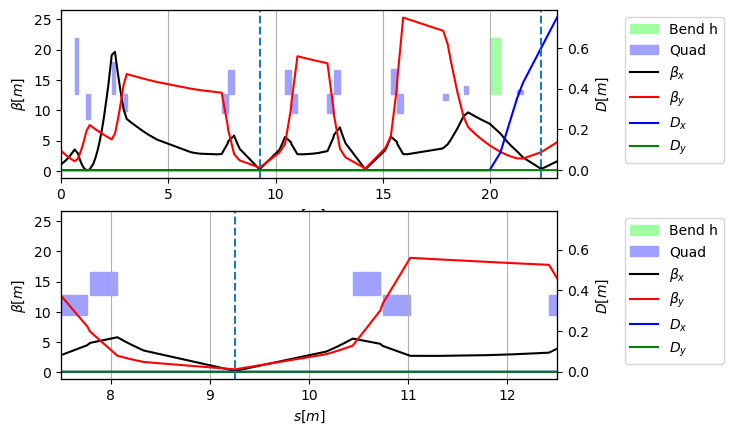

In [4]:
l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
p = xsuite_twiss['xtrack_particles']

# s location of IP
ip_idx = (t['name'] == "CLA-FEC1-SIM-FOCUS-01")
scr_idx = (t['name'] == "CLA-FED-DIA-SCR-02")

ip_s = t['s'][ip_idx][0]
scr_s = t['s'][scr_idx][0]

ip_betx = t['betx'][ip_idx][0]
ip_bety = t['bety'][ip_idx][0]
scr_betx = t['betx'][scr_idx][0]


print(ip_betx, ip_bety)
print(scr_betx)

ax = plt.subplot(2,1,1)
t.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(scr_s,ls="--")

# plt.xlim(7.5,12.5)

ax = plt.subplot(2,1,2)
t.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(scr_s,ls="--")
plt.xlim(7.5,12.5)


### Insert PMQs symmetrically around focus

Slicing line:   0%|          | 0/160 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/162 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/163 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/165 [00:00<?, ?it/s]

(7.5, 12.5)

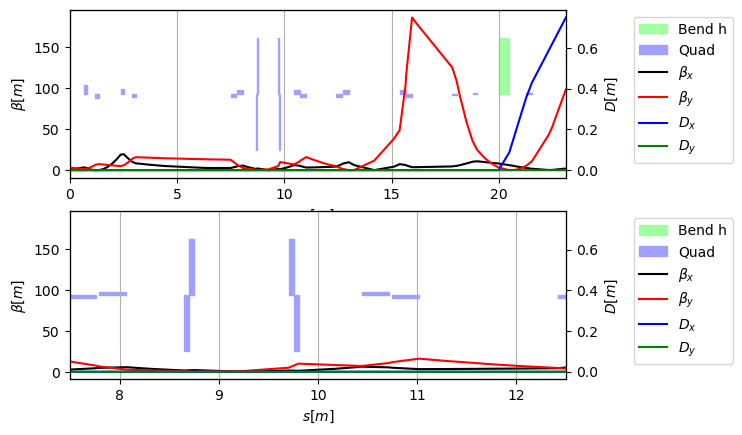

In [53]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

e = xsuite_twiss['env']
l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
t0d = xsuite_twiss['dict_twiss0']
p = xsuite_twiss['xtrack_particles']

hquadf = xtrack.Quadrupole(length=0.05,
                           k1=-119.400000)
hquadd = xtrack.Quadrupole(length=0.05,
                           k1=119.400000)

l.insert_element(element=hquadf,
                 name="HQUADF1",
                 at_s=ip_s-0.5-0.05)
l.insert_element(element=hquadd,
                 name="HQUADD1",
                 at_s=ip_s-0.5) 

l.insert_element(element=hquadd,
                 name="HQUADF2",
                 at_s=ip_s+0.5)
l.insert_element(element=hquadf,
                 name="HQUADD2",
                 at_s=ip_s+0.5+0.05-0.05)

t_pmq = l.twiss(method="4d",init=t0)

ax = plt.subplot(2,1,1)
t_pmq.plot(ax=ax)

ax = plt.subplot(2,1,2)
t_pmq.plot(ax=ax)
plt.xlim(7.5,12.5)

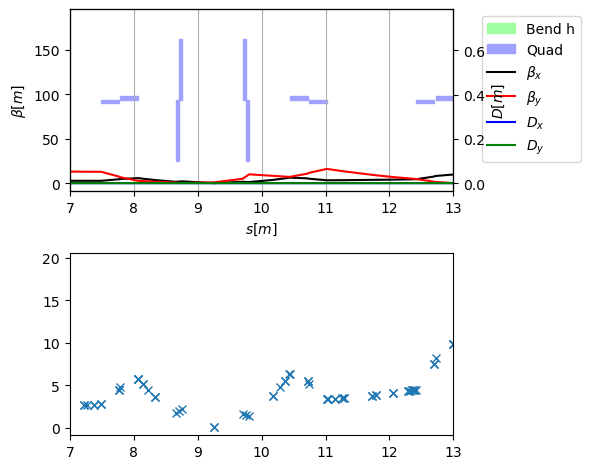

In [54]:
ax = plt.subplot(2,1,1)
t_pmq.plot(ax=ax)
plt.xlim(7,13)

ax = plt.subplot(2,1,2)
plt.plot(t_pmq['s'],t_pmq['betx'],"x")
plt.xlim(7,13)

plt.tight_layout()

In [26]:
opt = l.match(
    start='CLA-FEA-SIM-DIP-04-END', end='CLA-FED-SIM-DUMP-01-START',
    betx=t0d['betx'], bety=t0d['bety'],
    vary=xtrack.VaryList(['CLA-FEH-MAG-QUAD-01', 'CLA-FEH-MAG-QUAD-02'],
                         step=1e-10, limits=[-1e-3, 1e-3]),
    targets = [xtrack.TargetSet(y=3e-3, py=0, at='CLA-FEC1-SIM-FOCUS-01')])

KeyError: 'Variable `CLA-FEH-MAG-QUAD-01.k1` not found'

### Bruno solution

Fixed numbers $s$, $\beta_{x,y}$, $\alpha_{x,y}$ are from MAD8 notebook

Slicing line:   0%|          | 0/110 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/112 [00:00<?, ?it/s]

Mad8.readTwissFile > nrec=70


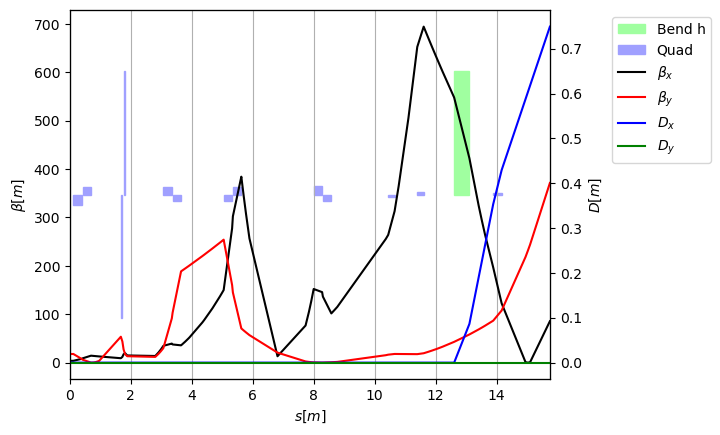

In [48]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEH-DIA-BPM-01",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
p = xsuite_twiss['xtrack_particles']

# insert magnets 
hquadf = xtrack.Quadrupole(length=0.05,
                           k1=-119.400000)
hquadd = xtrack.Quadrupole(length=0.05,
                           k1=119.400000)
ip = xtrack.Marker()

l.insert_element(element=hquadf,
                 name="HQUADF",
                 at_s=1.721332 + t['s'][t['name'] == "CLA-FEH-DIA-BPM-01"][0] - 0.05)
l.insert_element(element=hquadd,
                 name="HQUADD",
                 at_s=1.811221 + t['s'][t['name'] == "CLA-FEH-DIA-BPM-01"][0] - 0.05)   
l.insert_element(element=ip,
                 name="ip",
                 at_s=1.811221 + t['s'][t['name'] == "CLA-FEH-DIA-BPM-01"][0])
                 
# get magnet settings from Bruno MAD8
o = pybdsim.External.Pymad8.Output("../PMQ/TWISS_FEBE")

# CLAFEHMAGQUAD01 : 4
# CLAFEHMAGQUAD02 : 7

l.get("CLA-FEH-MAG-QUAD-01").k1 = o.getColumnsByKeys(['K1']).iloc[4]
l.get("CLA-FEH-MAG-QUAD-02").k1 = o.getColumnsByKeys(['K1']).iloc[7]

mad8_twiss0 = xtrack.TwissInit(betx = 3.73528,
                               alfx = -0.404159,
                               dx = 0,
                               dpx = 0,
                               bety = 17.8614,
                               alfy = -0.080607,
                               dy = 0,
                               dpy = 0)

t_pmq = l.twiss(method="4d",init=mad8_twiss0)
t_pmq.plot()

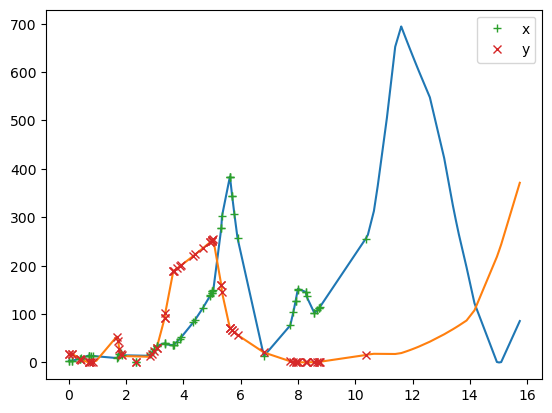

In [49]:
plt.plot(t_pmq['s'],t_pmq['betx'],"-")
plt.plot(t_pmq['s'],t_pmq['bety'],"-")

plt.plot(o.getColumnsByKeys(['S']),o.getColumnsByKeys(['BETX']),"+", label="x")
plt.plot(o.getColumnsByKeys(['S']),o.getColumnsByKeys(['BETY']),"x", label="y")

plt.legend()
#plt.xlim(0,6)
#plt.ylim(0,100)